[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509Files/blob/main/OPIM5509_Module2_Files/Assignment3.ipynb)

# Individual NN Classification Assignment (Spring 2024)
**Dr. Dave Wanik - University of Connecticut**

* Full Name: George Khramtchenko
* Student ID (7 digit number): 3325515

---------------------------------------------------------------------------

Each student must complete and submit their own file, but you may work with your group for help. I do not want to see direct copy and pasted code otherwise you will get a zero.

1. Read the data dictionary and description from here:

* https://oehha.ca.gov/media/downloads/calenviroscreen/document/calenviroscreen40resultsdatadictionaryf2021.zip

 Download the data using gdown, read the Excel file using pandas, print the first 10 rows using df.head() and use df.info() to examine the data types and missing values.

2. Simplify the raw dataframe so that you only keep the columns you need. The `X` variable will be the following columns: `Population`, `Ozone` through `Solid Waste Pctl`, and `Asthma` through `Linguistic Isolation Pctl`. The `y` variable will be `Poverty`. Examine the quality of each column and use your judgement about dropping rows or imputing missing values. Add text cells and lots of comments so we can understand your logic/justification!

3. Recode the target variable to a 1 if greater than the mean value of poverty, otherwise make it a 0. Use this recoded variable as the target variable! Now it is a classification problem.

4. Make two interesting plots or tables and a description of why you made the table and what you see.

5. Do an 90/10 split for X_train, X_test, y_train, y_test where the random seed is equal to your 7 digit studentID number.

6. Use the StandardScaler() on train and apply to test partition. Do not scale the target variable!

7. Build a model using the Sequential API (like we do in class) with at least 2 dense layers with the relu activation function, and with dropout in between each dense layer (use a number between 0.1 and 0.5). Compile the model using an appropriate optimizer. Use early stopping with patience of at least 10 and restore the best weights once the model converges. You can choose whatever batch size you would like to.

8. Fit the model for 100000 epochs with a batch size of your choice, using X_test and y_test as the validation data. **Don’t forget the early stopping callback!**

9. Evaluate the model using learning curves, error metrics and confusion matrices for each partition (like we do in class). You should largely be able to copy and paste this from class notebooks. Add a few bullet points about what you see (did your model learn nice and gently?  If you don't have text cells here, you will lose points.

10. Calculate what a baseline prediction would be for the train and test partitions (a mean only model). Did your model do better than the baseline predictions? If so, you have a useful model!

# Read Data and Import Modules

In [38]:
!pip install keras

In [39]:
# import modules
# for general data analysis/plotting
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# for data prep
from sklearn.model_selection import train_test_split

# neural net modules
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

In [40]:
# # https://docs.google.com/spreadsheets/d/1xkU-DBC8iF1X7e02y6h2Sr1OnBe0LAAi/edit?usp=sharing&ouid=113264555687147168472&rtpof=true&sd=true
!gdown 1xkU-DBC8iF1X7e02y6h2Sr1OnBe0LAAi # ID for Environmental Health data! look up!
# df_CalEnviroScreen = pd.read_excel('CalEnviroScreen.xlsx')

Downloading...
From: https://drive.google.com/uc?id=1xkU-DBC8iF1X7e02y6h2Sr1OnBe0LAAi
To: /content/CalEnviroScreen.xlsx
100% 5.08M/5.08M [00:00<00:00, 83.1MB/s]


In [41]:
# Link to the data file on Github
url = "https://github.com/drdave-teaching/OPIM5509Files/raw/main/OPIM5509_Module2_Files/CalEnviroScreen.xlsx"

# retrieve the data and build a dataframe
df_CalEnviroScreen = pd.read_excel(url)

df_CalEnviroScreen.shape

(8035, 57)

In [42]:
df_CalEnviroScreen.head()

,Census Tract,Total Population,California County,ZIP,Nearby City \n(to help approximate location only),Longitude,Latitude,CES 3.0 Score,CES 3.0 Percentile,CES 3.0 \nPercentile Range,...,Linguistic Isolation Pctl,Poverty,Poverty Pctl,Unemployment,Unemployment Pctl,Housing Burden,Housing Burden Pctl,Pop. Char.,Pop. Char. Score,Pop. Char. Pctl
0,6019001100,3174,Fresno,93706,Fresno,-119.781696,36.709695,94.090246,100.000000,95-100% (highest scores),...,77.509665,76.3,97.121307,17.6,91.724838,26.0,79.398324,92.120494,9.553509,99.697314
1,6071001600,6133,San Bernardino,91761,Ontario,-117.618013,34.057780,90.677839,99.987388,95-100% (highest scores),...,96.253833,72.5,94.632307,12.3,71.823836,34.1,93.754760,87.436849,9.067784,98.108210
2,6019000200,3167,Fresno,93706,Fresno,-119.805504,36.735491,85.970036,99.974776,95-100% (highest scores),...,78.389548,86.8,99.560025,16.1,87.980708,40.1,97.854785,94.581328,9.808714,99.987388
3,6077000801,6692,San Joaquin,95203,Stockton,-121.314524,37.940517,82.491521,99.962164,95-100% (highest scores),...,75.136648,61.3,85.568825,19.6,94.973981,21.1,63.544047,86.701266,8.991499,97.717241
4,6019001500,2206,Fresno,93725,Fresno,-119.717843,36.681600,82.030814,99.949552,95-100% (highest scores),...,73.723504,66.4,90.232558,18.6,93.654017,28.1,83.980706,80.075199,8.304332,92.760752


In [43]:
# read data
df = pd.read_excel('CalEnviroScreen.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8035 entries, 0 to 8034
Data columns (total 57 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Census Tract                                      8035 non-null   int64  
 1   Total Population                                  8035 non-null   int64  
 2   California County                                 8035 non-null   object 
 3   ZIP                                               8035 non-null   int64  
 4   Nearby City 
(to help approximate location only)  8035 non-null   object 
 5   Longitude                                         8035 non-null   float64
 6   Latitude                                          8035 non-null   float64
 7   CES 3.0 Score                                     7929 non-null   float64
 8    CES 3.0 Percentile                               7929 non-null   float64
 9   CES 3.0 
Percentile

**Prompt 2:** Simplify the raw dataframe so that you only keep the columns you need. The X variable will be the following columns: Population, Ozone through Solid Waste Pctl, and Asthma through Linguistic Isolation Pctl. The y variable will be Poverty. Examine the quality of each column and use your judgement about dropping rows or imputing missing values. Add text cells and lots of comments so we can understand your logic/justification!

Define the target variable `Poverty`and select the required columns for X.

In [44]:
# Define the target variable
y = df['Poverty']

# Define the reqruired feature columns as a list for future use below
columns_X = [
    'Total Population',
    'Ozone', 'Ozone Pctl', 'PM2.5', 'PM2.5 Pctl', 'Diesel PM', 'Diesel PM Pctl',
    'Drinking Water', 'Drinking Water Pctl', 'Pesticides', 'Pesticides Pctl',
    'Tox. Release', 'Tox. Release Pctl', 'Traffic', 'Traffic Pctl',
    'Cleanup Sites', 'Cleanup Sites Pctl', 'Groundwater Threats', 'Groundwater Threats Pctl',
    'Haz. Waste', 'Haz. Waste Pctl', 'Imp. Water Bodies', 'Imp. Water Bodies Pctl',
    'Solid Waste', 'Solid Waste Pctl',
    'Asthma', 'Asthma Pctl', 'Low Birth Weight', 'Low Birth Weight Pctl',
    'Cardiovascular Disease', 'Cardiovascular Disease Pctl', 'Education',
    'Education Pctl', 'Linguistic Isolation', 'Linguistic Isolation Pctl'
]

# Filter the dataframe for these columns
X = df[df.columns[df.columns.isin(columns_X)]]

# Drop rows where the target variable 'Poverty' is missing
df_clean = df.dropna(subset=['Poverty'])
X = df_clean[df.columns[df.columns.isin(columns_X)]]
y = df_clean['Poverty']

# Check shape to confirm expected output
print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')

Shape of X: (7956, 35)
Shape of y: (7956,)


Examine the columns in our new dataframe `X`.

In [45]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7956 entries, 0 to 8032
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Total Population             7956 non-null   int64  
 1   Ozone                        7956 non-null   float64
 2   Ozone Pctl                   7956 non-null   float64
 3   PM2.5                        7938 non-null   float64
 4   PM2.5 Pctl                   7938 non-null   float64
 5   Diesel PM                    7956 non-null   float64
 6   Diesel PM Pctl               7956 non-null   float64
 7   Drinking Water               7952 non-null   float64
 8   Drinking Water Pctl          7952 non-null   float64
 9   Pesticides                   7956 non-null   float64
 10  Pesticides Pctl              7956 non-null   float64
 11  Tox. Release                 7956 non-null   float64
 12  Tox. Release Pctl            7956 non-null   float64
 13  Traffic                

As seen from the `df.info()` executed above, numerous rows have missing values that need to be handled via either dropping them or imputting missing values. For simplicity, I will not drop any columns since the lowest number of rows in any given column is `7790 / 7956`, so instead I will simply substitue the missing rows with the mean value of the given column.

In [46]:
# Programmatically fill missing values with the mean of the currently targeted column
for col in X:
    X[col].fillna(X[col].mean(), inplace=True)

/tmp/ipython-input-1387271221.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mean(), inplace=True)
/tmp/ipython-input-1387271221.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col].fillna(X[col].mean(), inplace=True)


Check how many non-null rows exist now using `X.info()`.

In [47]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7956 entries, 0 to 8032
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Total Population             7956 non-null   int64  
 1   Ozone                        7956 non-null   float64
 2   Ozone Pctl                   7956 non-null   float64
 3   PM2.5                        7956 non-null   float64
 4   PM2.5 Pctl                   7956 non-null   float64
 5   Diesel PM                    7956 non-null   float64
 6   Diesel PM Pctl               7956 non-null   float64
 7   Drinking Water               7956 non-null   float64
 8   Drinking Water Pctl          7956 non-null   float64
 9   Pesticides                   7956 non-null   float64
 10  Pesticides Pctl              7956 non-null   float64
 11  Tox. Release                 7956 non-null   float64
 12  Tox. Release Pctl            7956 non-null   float64
 13  Traffic                

Perfect! We now have an identical number of rows for each column. Now lets recode the target variable to a 1 if it is greater than the mean value of poverty, otherwise I will make it a 0. I will additionally use this recoded variable as the target variable to ensure this transforms into a classification problem.

**Prompt 3:** Recode the target variable to a 1 if greater than the mean value of poverty, otherwise make it a 0. Use this recoded variable as the target variable! Now it is a classification problem.

In [48]:
# Calculate the mean of the poverty column
poverty_mean = y.mean()
print(f"Mean of the Poverty column: {poverty_mean}")

# Recode the target variable to 1 if greater than the mean, else 0
y = (y > poverty_mean).astype(int)

# Display the value counts to check the distribution
print("\nTarget Variable Distribution:")
print(y.value_counts())
display(y.head())

Mean of the Poverty column: 36.38678984414278

Target Variable Distribution:
Poverty
0    4320
1    3636
Name: count, dtype: int64


,Poverty
0,1
1,1
2,1
3,1
4,1


Recoding completed. Now we have a classification problem.

**Prompt 4:** Make two interesting plots or tables and a description of why you made the table and what you see.

/tmp/ipython-input-2922911316.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


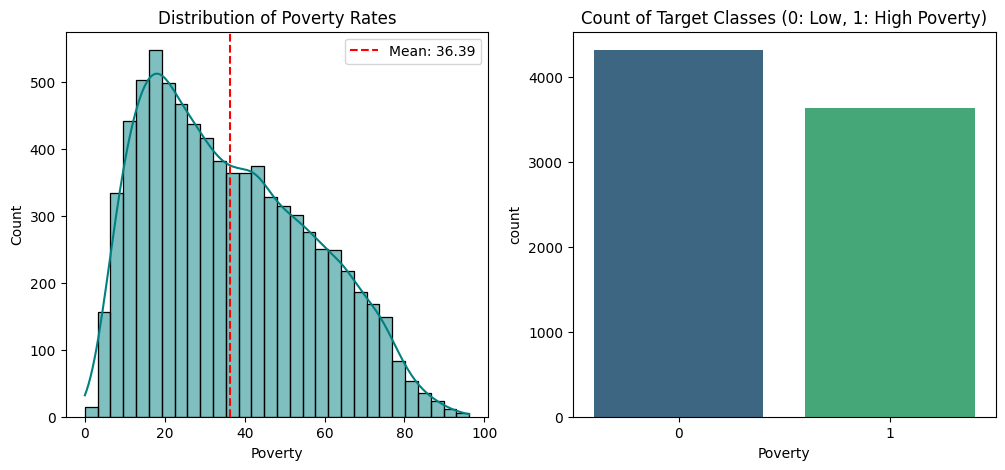

In [49]:
import seaborn as sns

# Plot 1: Distribution of Poverty vs Binary Target
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['Poverty'], kde=True, color='teal')
plt.axvline(poverty_mean, color='red', linestyle='--', label=f'Mean: {poverty_mean:.2f}')
plt.title('Distribution of Poverty Rates')
plt.legend()

# Plot 2: Target class counts (zero and one)
plt.subplot(1, 2, 2)
sns.countplot(x=y, palette='viridis')
plt.title('Count of Target Classes (0: Low, 1: High Poverty)')
plt.show()

The first plot on the left shows the continuous distribution of poverty levels across census tracts, with a red line indicating the threshold. The second plot on the right shows the resulting class balance, indicating a relatively even split for our classification model, which is important, as it ensures no biases exist which prevent the model from failing to learn the minority class, which is one.

**Prompt 5:** Do an 90/10 split for X_train, X_test, y_train, y_test where the random seed is equal to your 7 digit studentID number.

In [50]:
# My student ID
student_id = 3325515

# Partition into X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=student_id)

print(f'Training features shape: {X_train.shape}')
print(f'Testing features shape: {X_test.shape}')

Training features shape: (7160, 35)
Testing features shape: (796, 35)


**Prompt 6:** Use the StandardScaler() on train and apply to test partition. Do not scale the target variable!

In [51]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both partitions
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Prompt 7:** Build a model using the Sequential API (like we do in class) with at least 2 dense layers with the relu activation function, and with dropout in between each dense layer (use a number between 0.1 and 0.5). Compile the model using an appropriate optimizer. Use early stopping with patience of at least 10 and restore the best weights once the model converges. You can choose whatever batch size you would like to.

In [52]:
# Create the sequential model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile the model using binary_crossentropy as in lecture video
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define early stopping
es = EarlyStopping(monitor='val_loss',
                         patience=15,
                         restore_best_weights=True)

# Print model summary showing the layers, output shape, and number of parameters
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,697 (6.63 KB)

 Trainable params: 1,697 (6.63 KB)

 Non-trainable params: 0 (0.00 B)

**Prompt 8:** Fit the model for 100000 epochs with a batch size of your choice, using X_test and y_test as the validation data. **Don’t forget the early stopping callback!**

In [53]:
# Prompt 8: Fit the model
history = model.fit(X_train_scaled, y_train,
                    epochs=100000,
                    batch_size=32,
                    validation_data=(X_test_scaled, y_test),
                    callbacks=[es],
                    verbose=1)

Epoch 1/100000
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7079 - loss: 0.5594 - val_accuracy: 0.8530 - val_loss: 0.3474
Epoch 2/100000
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8465 - loss: 0.3614 - val_accuracy: 0.8668 - val_loss: 0.3256
Epoch 3/100000
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8565 - loss: 0.3405 - val_accuracy: 0.8706 - val_loss: 0.3165
Epoch 4/100000
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8613 - loss: 0.3350 - val_accuracy: 0.8681 - val_loss: 0.3124
Epoch 5/100000
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8609 - loss: 0.3277 - val_accuracy: 0.8706 - val_loss: 0.3119
Epoch 6/100000
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8722 - loss: 0.3200 - val_accuracy: 0.8781 - val_loss: 0.3124
Epoch 7/100000
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8622 - loss: 0.3224 - val_accuracy: 0.8756 - val_loss: 0.3082
Epoch 8/100000
224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8660 -

**Prompt 9:** Evaluate the model using learning curves, error metrics and confusion matrices for each partition (like we do in class). You should largely be able to copy and paste this from class notebooks. Add a few bullet points about what you see (did your model learn nice and gently? If you don't have text cells here, you will lose points.

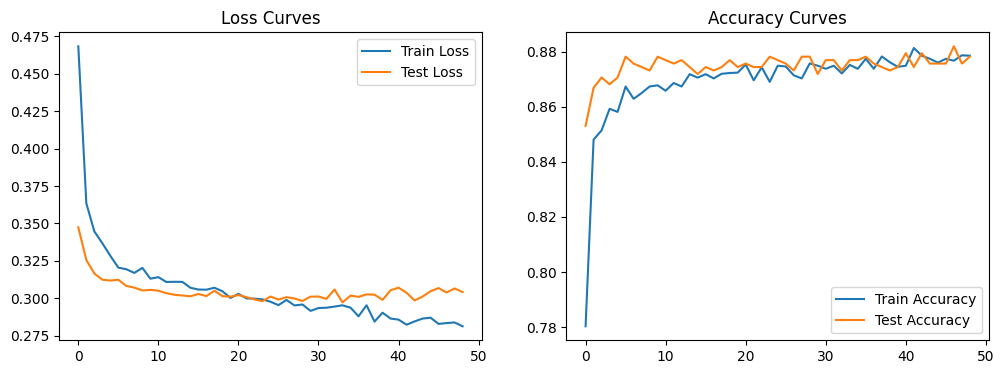

In [54]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Plot train and test loss curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss Curves')
plt.legend()

# Plot train and test accuracy scores
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


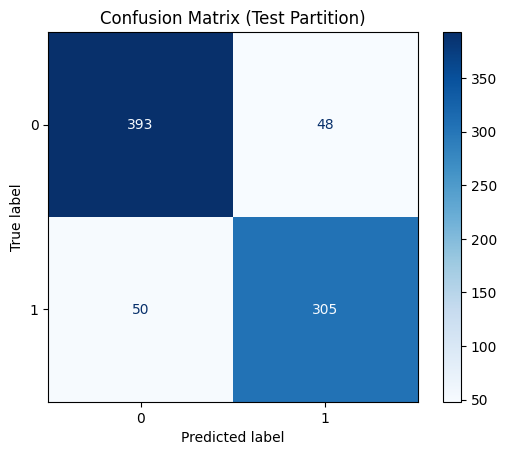

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       441
           1       0.86      0.86      0.86       355

    accuracy                           0.88       796
   macro avg       0.88      0.88      0.88       796
weighted avg       0.88      0.88      0.88       796



In [55]:
# Prediction for test partition
y_pred_test = (model.predict(X_test_scaled) > 0.5).astype(int)

# Confusion Matrix for Test Set
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Test Partition)')
plt.show()

# Display classification report
print(classification_report(y_test, y_pred_test))

We see incredibly strong values for all of the metrics that are displayed here in the classification report. This means that the model performs very well on both classes and is accurately able to predict the target variable!

**Prompt 10:** Calculate what a baseline prediction would be for the train and test partitions (a mean only model). Did your model do better than the baseline predictions? If so, you have a useful model!

In [56]:
# A simple baseline to predict the most frequent class
most_frequent_train = y_train.value_counts().idxmax()
baseline_train_acc = (y_train == most_frequent_train).mean()
baseline_test_acc = (y_test == most_frequent_train).mean()

# Print baseline accuracies for train and test
print(f'Baseline Accuracy (Train): {baseline_train_acc:.4f}')
print(f'Baseline Accuracy (Test): {baseline_test_acc:.4f}')

final_test_acc = history.history['val_accuracy'][-1]
if final_test_acc > baseline_test_acc:
    print(f'\nMy model ({final_test_acc:.4f}) beat the baseline of ({baseline_test_acc:.4f}).')
else:
    print('Unfortunately, model did not beat the baseline.')

Baseline Accuracy (Train): 0.5418
Baseline Accuracy (Test): 0.5540

My model (0.8781) beat the baseline of (0.5540).


Yes, my model did better than the baseline predictions, which means it is useful!